In [2]:
import torch
import torch.nn as nn
from torch.nn.functional import relu
import rasterio
#import numpy as np
import os
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib
print(matplotlib.__version__)
import random
from functools import reduce
import itertools
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets, models
from collections import defaultdict
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy

3.10.8


In [3]:
# --- Cell 2: The Model Architecture ---
# works slightly better than the og but doesnt do the job...
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=4):
        super().__init__()
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))

        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv_up1 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv_up2 = DoubleConv(256, 128)
        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv_up3 = DoubleConv(128, 64)
        self.outc = nn.Conv2d(64, n_classes, 1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x = self.up1(x4)
        x = self.conv_up1(torch.cat([x, x3], dim=1))  # Skip connections are key!
        x = self.up2(x)
        x = self.conv_up2(torch.cat([x, x2], dim=1))
        x = self.up3(x)
        x = self.conv_up3(torch.cat([x, x1], dim=1))
        # Return raw logits for multi-class segmentation with F.cross_entropy.
        return self.outc(x)

In [4]:
import rasterio
import numpy as np

def load_and_preprocess(path):
    with rasterio.open(path) as src:
        # Read all bands
        img = src.read()

        # Replace No-Data (example: -9999) with 0
        img[img == src.nodata] = 0

        # Robust Scaling (2nd and 98th percentile to remove outliers)
        p2, p98 = np.percentile(img, (2, 98))
        img = np.clip(img, p2, p98)
        img = (img - p2) / (p98 - p2)

    return img.astype(np.float32)
# Helper function to load raw mask data (without scaling or robust percentile clipping)
# Assumes single-channel mask where pixel values are class labels
def load_raw_mask(path):
    with rasterio.open(path) as src:
        mask_np = src.read()
        # Replace No-Data with 0 (or a specific background class ID)
        if src.nodata is not None:
            mask_np[mask_np == src.nodata] = 0

        # Recode classes 2 and 3 to 0
        #mask_np[mask_np == 2] = 0
        #mask_np[mask_np == 3] = 0

    return mask_np.astype(np.int64) # Masks are typically integer class labels
import os

def get_filename_without_extension(file_path):
    # Extract the base name (filename + extension) from the full path
    base_name = os.path.basename(file_path)
    # Split the base name into root and extension, and return the root
    file_name_without_extension = os.path.splitext(base_name)[0]
    return file_name_without_extension

In [5]:


def plot_img_array(img_array, ncol=3):
    # Calculate nrow, ensuring at least 1 row, and rounding up
    nrow = (len(img_array) + ncol - 1) // ncol
    if nrow == 0: # Handle empty img_array case
        return

    f, plots = plt.subplots(nrow, ncol, sharex='all', sharey='all', figsize=(ncol * 4, nrow * 4))

    # Flatten the plots array for consistent indexing across all cases
    # If plt.subplots returns a single Axes object (nrow=1, ncol=1), make it an array
    if not isinstance(plots, np.ndarray):
        plots = np.array([plots])
    else:
        plots = plots.ravel() # Flatten 2D array or keep 1D array as is

    for i in range(len(img_array)):
        plots[i].imshow(img_array[i])
        plots[i].axis('off') # Turn off axes for individual plots

    # Hide any remaining empty subplots
    for i in range(len(img_array), len(plots)):
        plots[i].axis('off')

    plt.tight_layout()
    plt.show()


def plot_side_by_side(img_arrays):
    flatten_list = reduce(lambda x,y: x+y, zip(*img_arrays))

    plot_img_array(np.array(flatten_list), ncol=len(img_arrays))


def plot_errors(results_dict, title):
    markers = itertools.cycle(('+', 'x', 'o'))

    plt.title('{}'.format(title))

    for label, result in sorted(results_dict.items()):
        plt.plot(result, marker=next(markers), label=label)
        plt.ylabel('dice_coef')
        plt.xlabel('epoch')
        plt.legend(loc=3, bbox_to_anchor=(1, 0))

    plt.show()


def reverse_transform(inp):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    inp = (inp * 255).astype(np.uint8)

    return inp

def masks_to_colorimg(masks, threshold = 0.5):
    # For binary segmentation with single-channel output representing the foreground class (road)
    # Input 'masks' is (1, H, W) for ground truth (0 or 1) or predictions (probabilities)

    # Create a 3-channel (RGB) image, initially white
    height, width = masks.shape[1], masks.shape[2]
    colorimg = np.ones((height, width, 3), dtype=np.float32) * 255

    # Define colors for background and foreground
    background_color = np.asarray([255, 255, 255]) # White for background
    foreground_color = np.asarray([0, 0, 255])   # Blue for road

    # Apply a threshold to determine foreground pixels
    # For ground truth masks, threshold effectively checks for value 1
    # For prediction masks, threshold applies to probabilities
    # Default threshold for predictions. For GT, any non-zero is foreground.

    # Assuming masks is (1, H, W), so we work with masks[0]
    foreground_pixels = masks[0] > threshold

    # Set color for foreground pixels
    colorimg[foreground_pixels] = foreground_color

    return colorimg.astype(np.uint8)


In [6]:
from torch.utils.data import Dataset
from PIL import Image
import torch
from torchvision import transforms
import rasterio
import numpy as np

class TrainingDataset(Dataset):
    def __init__(self, image_paths, label_paths, transform=None, num_classes=1): # Changed num_classes to 1
        self.image_paths = image_paths
        self.label_paths = label_paths
        self.transform = transform # This transform is for images
        self.num_classes = num_classes # Will always be 1 for binary segmentation
        print("using the one with binary segmentation")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        # Load image as NumPy array (C, H, W, float32) using the provided function
        image_np = load_and_preprocess(self.image_paths[index])

        # Load mask as NumPy array (1, H, W, int64) using the new helper function
        mask_np_raw = load_raw_mask(self.label_paths[index])

        # Apply class remapping: combine classes 2 and 3 into class 1, other non-zero to 1, all others to 0
        # Now we want a binary mask: 1 for road, 0 for background
        # Original values: 0 (background), 1 (road), 2 (building), 3 (vehicle)
        # We want: 1 (road), 0 (all others)
        mask_np_raw = np.where(mask_np_raw == 1, 1, 0) # Only class 1 (road) becomes 1, everything else becomes 0

        # Convert image_np (C, H, W) to a PIL Image (H, W, C) for torchvision transforms
        # which expect PIL Image for operations like Resize
        if image_np.shape[0] == 3: # Assuming RGB
            # Multiply by 255 and convert to uint8 before creating PIL Image
            image_pil = Image.fromarray((image_np.transpose(1, 2, 0) * 255).astype(np.uint8))
        elif image_np.shape[0] == 4: # Assuming RGB-NIR, take only RGB
            # Select the first 3 channels (R, G, B) and transpose for PIL
            image_pil = Image.fromarray((image_np[:3, :, :].transpose(1, 2, 0) * 255).astype(np.uint8))

        elif image_np.shape[0] == 1: # Assuming grayscale
            image_pil = Image.fromarray((image_np.squeeze(0) * 255).astype(np.uint8))
        else:
            raise ValueError(f"Unsupported image channel count: {image_np.shape[0]} for PIL conversion")

        # Apply the image transform (includes Resize, ToTensor, Normalize)
        if self.transform:
            image_tensor = self.transform(image_pil)
        else:
            # If no transform is provided, at least convert to tensor
            image_tensor = transforms.ToTensor()(image_pil)

        # Determine the target size for the mask from the transformed image
        target_size = image_tensor.shape[-2:] # Get (H, W) from the image tensor

        # Convert raw mask (1, H, W) to PyTorch Tensor (float32 for BCEWithLogitsLoss)
        mask_tensor = torch.from_numpy(mask_np_raw).float()

        # Resize the mask using nearest neighbor interpolation
        # Ensure mask_tensor is (C, H, W) for Resize, then (1, H, W) float
        mask_resized = transforms.Resize(target_size, interpolation=transforms.InterpolationMode.NEAREST)(
            mask_tensor
        )

        # For binary segmentation, the target should be a single-channel float tensor
        # (N, 1, H, W). Our mask_resized is (1, H, W) so it's ready.
        return image_tensor, mask_resized

print("TrainingDataset class defined for binary segmentation.")

TrainingDataset class defined for binary segmentation.


In [7]:
import os
import glob
import random
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import DataLoader
import torch
import numpy as np

def get_data_loaders(batch_size=4, subset_size=None, undersampling_ratio=0.0, minority_class_threshold=0.2, path = '/Users/yujiewu/SP/haiti_cropped_smaller/'):
    base_path = path
    image_dir = os.path.join(base_path, 'images-pre-disaster')
    label_dir = os.path.join(base_path, 'labels-pre-disaster')

    all_image_paths = sorted(glob.glob(os.path.join(image_dir, '*.tif')))
    all_label_paths = sorted(glob.glob(os.path.join(label_dir, '*.tif')))

    if len(all_image_paths) != len(all_label_paths):
        raise ValueError("Mismatch between number of images and labels.")

    # Pair image and label paths
    all_pairs = list(zip(all_image_paths, all_label_paths))

    # Split all pairs into training and validation sets
    train_pairs, val_pairs = train_test_split(all_pairs, test_size=0.2, random_state=42)

    # --- Undersampling for the training set --- (not using)
    if subset_size is not None:
        final_train_pairs = train_pairs[:subset_size]#final_train_pairs[:subset_size]
        val_pairs = val_pairs[:subset_size // 4] # Keep validation subset smaller if train is subsetted
    #else:
    #  val_pairs = val_pairs[:len(final_train_pairs) // 4]
    train_image_paths = [p[0] for p in train_pairs]#final_train_pairs]
    train_label_paths = [p[1] for p in train_pairs]#final_train_pairs]

    val_image_paths = [p[0] for p in val_pairs]
    val_label_paths = [p[1] for p in val_pairs]

    print(f"Training images (using pre-undersampled drive): {len(train_image_paths)}")
    print(f"Validation images: {len(val_image_paths)}")

    # Define image transformations
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    image_size = (256, 256) # Define target image size, further reduced for faster verification
    #print(f"get_data_loaders: Setting image_size to {image_size}")

    train_transform = transforms.Compose([
        transforms.Resize(image_size),
        #transforms.RandomHorizontalFlip(),
        #transforms.RandomVerticalFlip(),
        #transforms.RandomRotation(degrees=10),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

    val_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

    train_dataset = TrainingDataset(
        image_paths=train_image_paths,
        label_paths=train_label_paths,
        transform=train_transform
    )

    val_dataset = TrainingDataset(
        image_paths=val_image_paths,
        label_paths=val_label_paths,
        transform=val_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    return {'train': train_loader, 'val': val_loader}

print("Function `get_data_loaders` defined with undersampling capability.")


Function `get_data_loaders` defined with undersampling capability.


In [8]:
def dice_loss(pred, target, smooth=1.):
    pred = pred.contiguous()
    target = target.contiguous()

    intersection = (pred * target).sum(dim=2).sum(dim=2)

    loss = (1 - ((2. * intersection + smooth) / (pred.sum(dim=2).sum(dim=2) + target.sum(dim=2).sum(dim=2) + smooth)))

    return loss


def calc_loss(pred, target, metrics, bce_weight=0.5, pos_weight=None):
    # Ensure pos_weight is on the correct device if provided
    if pos_weight is not None:
        pos_weight = pos_weight.to(pred.device)
        bce = F.binary_cross_entropy_with_logits(pred, target, pos_weight=pos_weight)
    else:
        bce = F.binary_cross_entropy_with_logits(pred, target)

    # Apply sigmoid for Dice loss calculation
    pred_sigmoid = torch.sigmoid(pred)
    # dice_loss returns a tensor of shape (N, 1) where each element is (1 - Dice_score)
    dice_per_sample = dice_loss(pred_sigmoid, target)

    # For Dice loss, typically mean over samples is taken.
    weighted_dice = dice_per_sample.mean()

    loss = bce * bce_weight + weighted_dice * (1 - bce_weight)

    metrics['bce'] += bce.data.cpu().numpy() * target.size(0)
    metrics['dice'] += weighted_dice.data.cpu().numpy() * target.size(0)
    metrics['loss'] += loss.data.cpu().numpy() * target.size(0)

    return loss


def print_metrics(metrics, epoch_samples, phase):
    outputs = []
    for k in metrics.keys():
        outputs.append("{}: {:4f}".format(k, metrics[k] / epoch_samples))

    print("{}: {}".format(phase, ", ".join(outputs)))


def train_model(model, optimizer, scheduler, num_epochs=25, subset_size=None, pos_weight=None):
    dataloaders = get_data_loaders(subset_size=subset_size) # Passed subset_size to get_data_loaders
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = 1e10

    # Initialize dictionaries to store metrics for plotting
    history = defaultdict(list)

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        since = time.time()

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()  # Set model to evaluate mode

            metrics = defaultdict(float)
            epoch_samples = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = calc_loss(outputs, labels, metrics, pos_weight=pos_weight) # Pass pos_weight

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                        # Move scheduler.step() after optimizer.step()

                # statistics
                epoch_samples += inputs.size(0)

            scheduler.step()

            print_metrics(metrics, epoch_samples, phase)
            epoch_loss = metrics['loss'] / epoch_samples
            epoch_bce = metrics['bce'] / epoch_samples
            epoch_dice = metrics['dice'] / epoch_samples

            # Store metrics in history
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_bce'].append(epoch_bce)
            history[f'{phase}_dice'].append(epoch_dice)

            # deep copy the model
            if phase == 'val' and epoch_loss < best_loss:
                print("saving best model")
                best_loss = epoch_loss
                best_model_wts = copy.deepcopy(model.state_dict())

        time_elapsed = time.time() - since
        print('{:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))

    print('Best val loss: {:4f}'.format(best_loss))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

In [17]:
import torch

# Explicitly call get_data_loaders to ensure it uses the latest definitions
# We pass a batch_size of 4 here to match the expected output shape for verification.
dataloaders = get_data_loaders(batch_size=4)

# Get the first batch of images and labels
inputs, labels = next(iter(dataloaders['train']))

# Print the shape of the inputs (images)
print(f"Shape of images in the batch: {inputs.shape}")

# Expected shape: [batch_size, channels, height, width]
# For 192x192 images and batch_size=4, this should be torch.Size([4, 3, 192, 192])

Training images (using pre-undersampled drive): 281
Validation images: 71
using the one with binary segmentation
using the one with binary segmentation
Shape of images in the batch: torch.Size([4, 3, 256, 256])


2026-04-01 20:29:36.737414-07:00
Calculated pos_weight for BCE: 1.00
Training images (using pre-undersampled drive): 281
Validation images: 71
using the one with binary segmentation
using the one with binary segmentation
Epoch 0/24
----------
train: bce: 0.507193, dice: 0.367913, loss: 0.437553
val: bce: 0.603988, dice: 0.324222, loss: 0.464105
saving best model
1m 47s
Epoch 1/24
----------
train: bce: 0.467686, dice: 0.335476, loss: 0.401581
val: bce: 0.711888, dice: 0.393646, loss: 0.552767
1m 42s
Epoch 2/24
----------
train: bce: 0.447560, dice: 0.316421, loss: 0.381990
val: bce: 0.447577, dice: 0.317349, loss: 0.382463
saving best model
1m 39s
Epoch 3/24
----------
train: bce: 0.428620, dice: 0.311254, loss: 0.369938
val: bce: 0.434491, dice: 0.327741, loss: 0.381116
saving best model
1m 27s
Epoch 4/24
----------
train: bce: 0.404910, dice: 0.294882, loss: 0.349896
val: bce: 0.341278, dice: 0.291201, loss: 0.316240
saving best model
1m 26s
Epoch 5/24
----------
train: bce: 0.425113

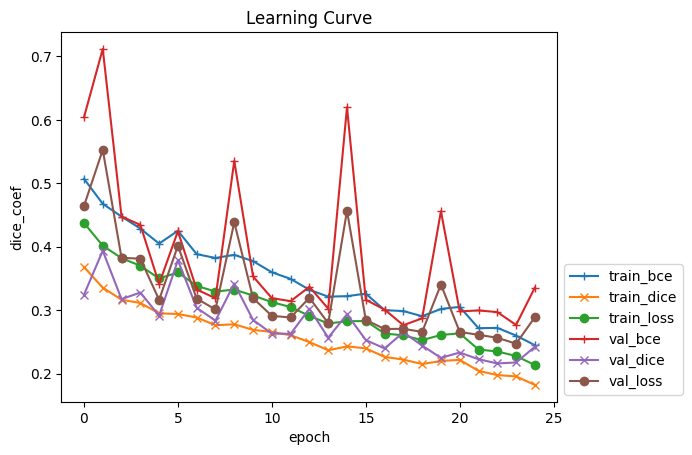

Training images (using pre-undersampled drive): 281
Validation images: 3
using the one with binary segmentation
using the one with binary segmentation
(3, 1, 256, 256)


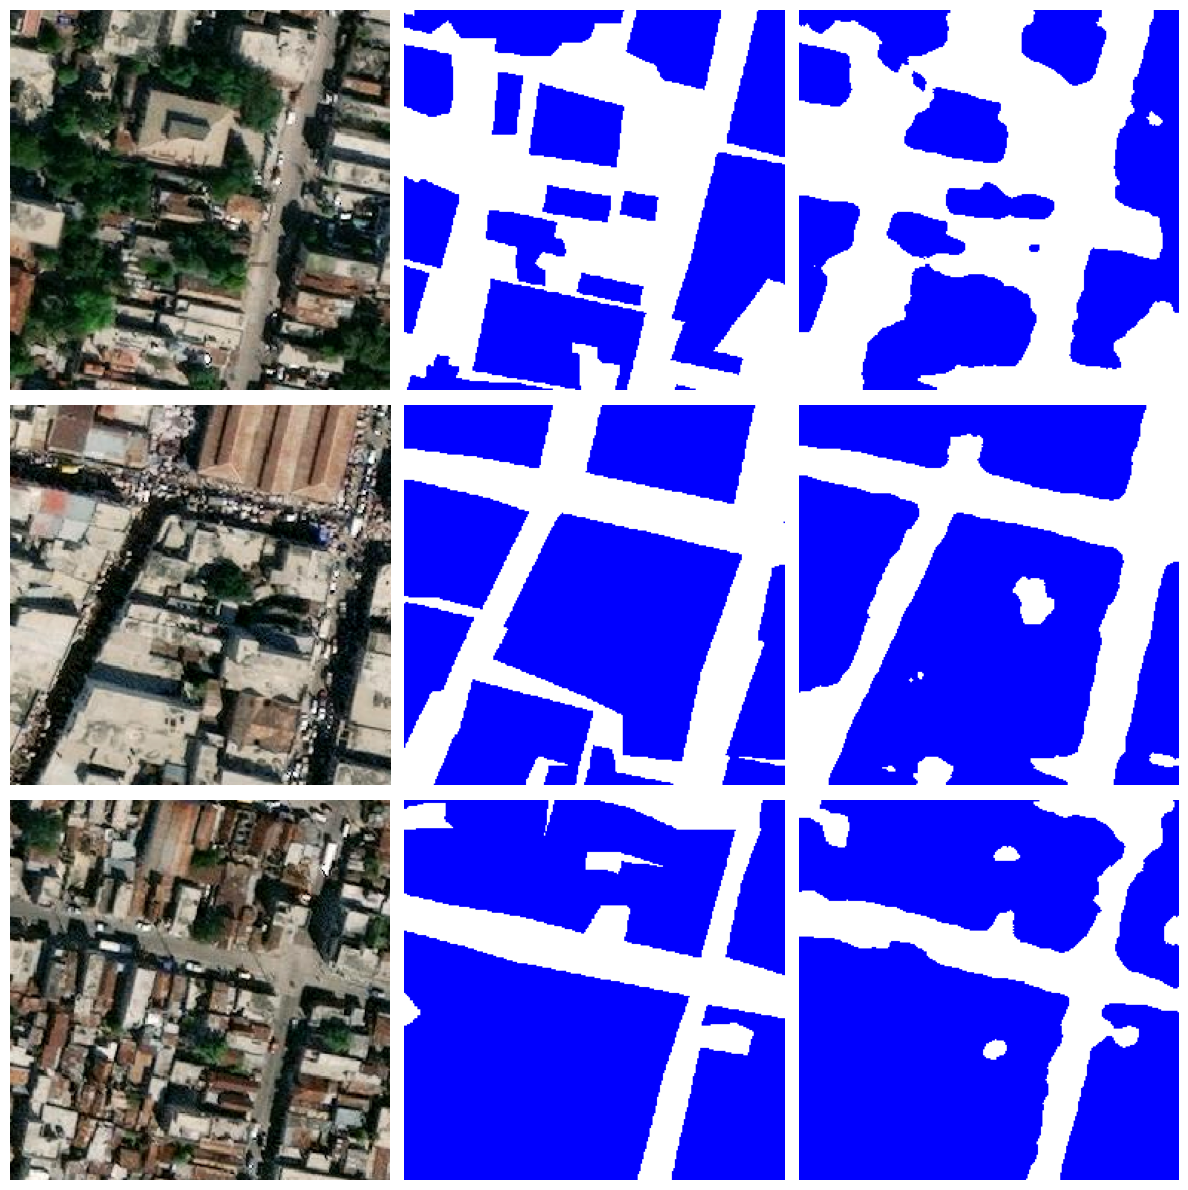

In [31]:
from datetime import datetime
from zoneinfo import ZoneInfo

# Get the current time in a specific timezone (e.g., 'US/Pacific')
tz = ZoneInfo('US/Pacific')
current_time_tz = datetime.now(tz);

# Print the timezone-aware time
print(current_time_tz);

num_class = 1 # Set num_class to 1 for binary segmentation (road vs. background)
num_epochs = 25 #one epoch is 2-3 min
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

pos_weight_val = 1 #TEMPORARY
pos_weight = torch.tensor([pos_weight_val], dtype=torch.float32)
print(f"Calculated pos_weight for BCE: {pos_weight_val:.2f}")

model = UNet(n_classes=num_class).to(device)

optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-4)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=60, gamma=0.1)

model, history = train_model(model, optimizer_ft, exp_lr_scheduler, num_epochs=num_epochs, subset_size = 1600, pos_weight=pos_weight)
torch.save(model.state_dict(), '/Users/yujiewu/SP/model-saves/unet-detect-house.pth')

# Plot learning curves
plot_errors(history, 'Learning Curve')

model.eval()  # Set model to the evaluation mode

# Re-initialize dataloaders for testing/visualization, also with the small subset
test_dataloaders = get_data_loaders(batch_size=3, subset_size=15) # Get 3 samples for plotting from the small subset
test_loader = test_dataloaders['val'] # Use the validation set as test set for visualization

# Get the first batch
inputs, labels = next(iter(test_loader))
inputs = inputs.to(device)
labels = labels.to(device)

# Predict
pred = model(inputs)
# The loss functions include the sigmoid function. Apply sigmoid to get probabilities.
pred = F.sigmoid(pred)
pred = pred.data.cpu().numpy()
print(pred.shape)

# Change channel-order and make 3 channels for matplot
input_images_rgb = [reverse_transform(x) for x in inputs.cpu()]

# Map each channel (i.e. class) to each color (labels and predictions will be single channel)
target_masks_rgb = [masks_to_colorimg(x) for x in labels.cpu().numpy()]
pred_rgb = [masks_to_colorimg(x, threshold = 0.5) for x in pred]

plot_side_by_side([input_images_rgb, target_masks_rgb, pred_rgb])
#return pred, labels, inputs # Return pred, labels, and inputs for further analysis

228
(1, 1, 256, 256)


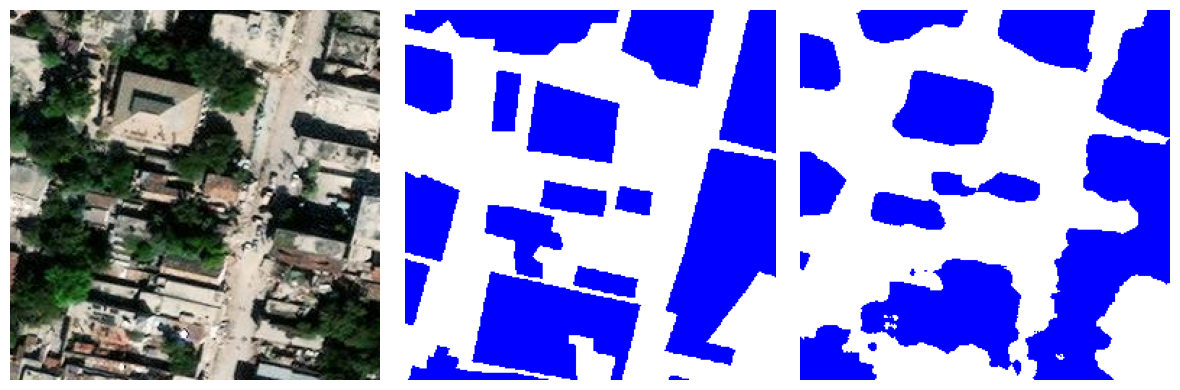

In [24]:
#display prediction output for any image path

inputs_dir = '/Users/yujiewu/SP/haiti_cropped_smaller/images'
inputs_list = sorted(glob.glob(os.path.join(inputs_dir, '*.tif')))
labels_list = sorted(glob.glob(os.path.join('/Users/yujiewu/SP/haiti_cropped_smaller/labels', '*.tif')))

idx = 228#random.randint(0, len(inputs_list) - 1)

input = inputs_list[idx]
print(idx)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = UNet(n_classes=1).to(device)
model.load_state_dict(torch.load('/Users/yujiewu/SP/model-saves/unet-detect-house.pth', map_location=device))
model.eval()  # Set model to the evaluation mode

#transform input to the correct format to pass through the model
image_np = load_and_preprocess(input)
#image_pil = Image.fromarray((image_np.transpose(1, 2, 0) * 255).astype(np.uint8))
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
#image_tensor = transform(image_pil).unsqueeze(0).to(device) # Add batch dimension and move to device   
image_pil = Image.fromarray((image_np[:3, :, :].transpose(1, 2, 0) * 255).astype(np.uint8))
image_tensor = transform(image_pil).unsqueeze(0).to(device) # Add batch dimension and move to device

#predict
with torch.no_grad():
    pred = model(image_tensor)
    pred = F.sigmoid(pred).cpu().numpy() # Apply sigmoid to get probabilities and move to CPU for numpy conversion
    print(pred.shape)

#display original image, predicted mask, and label
mask_np = load_raw_mask(labels_list[idx])
mask_tensor = torch.from_numpy(mask_np).float()

input_image_rgb = reverse_transform(image_tensor.squeeze(0).cpu())
pred_mask_rgb = masks_to_colorimg(pred[0], threshold=0.5)
label_rgb = masks_to_colorimg(mask_tensor, threshold=0.5)

plot_side_by_side([[input_image_rgb], [label_rgb], [pred_mask_rgb]])



In [ ]:
import torch
import numpy as np

class SegmentationMetrics:
    """
    Accumulates a confusion matrix over the full val set,
    then computes per-class and mean IoU + F1.
    """
    def __init__(self, num_classes: int, class_names: list[str], ignore_index: int = 255):
        self.num_classes = num_classes
        self.class_names = class_names
        self.ignore_index = ignore_index
        self.reset()

    def reset(self):
        self.confusion_matrix = np.zeros((self.num_classes, self.num_classes), dtype=np.int64)

    def update(self, preds: torch.Tensor, targets: torch.Tensor):
        """
        preds:   (B, H, W) — argmax class indices
        targets: (B, H, W) — ground truth class indices
        """
        preds = preds.cpu().numpy().flatten()
        targets = targets.cpu().numpy().flatten()

        # Mask out ignored pixels
        mask = targets != self.ignore_index
        preds, targets = preds[mask], targets[mask]

        # Accumulate into confusion matrix
        indices = self.num_classes * targets + preds
        counts = np.bincount(indices, minlength=self.num_classes ** 2)
        self.confusion_matrix += counts.reshape(self.num_classes, self.num_classes)

    def compute(self) -> dict:
        cm = self.confusion_matrix  # shape: (C, C)

        # Per-class IoU
        tp = np.diag(cm)                          # true positives per class
        fp = cm.sum(axis=0) - tp                  # false positives
        fn = cm.sum(axis=1) - tp                  # false negatives

        iou = tp / (tp + fp + fn + 1e-6)

        # Per-class F1
        precision = tp / (tp + fp + 1e-6)
        recall    = tp / (tp + fn + 1e-6)
        f1 = 2 * precision * recall / (precision + recall + 1e-6)

        results = {
            "per_class_iou":  dict(zip(self.class_names, iou)),
            "per_class_f1":   dict(zip(self.class_names, f1)),
            "miou":           float(np.mean(iou)),
            "mean_f1":        float(np.mean(f1)),
        }
        return results
    


dataloader = get_data_loaders()
# Get a sample from the validation dataset
val_dataset = dataloader['val']
metrics_calculator = SegmentationMetrics(num_classes=2, class_names=["background", "building"], ignore_index=255)
#iterate through entire val dataset and calculate mIoU for each class and mean IoU
ious_per_class = []
mean_ious = []
for inputs, labels in val_dataset:
    inputs = inputs.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        outputs = model(inputs)
        logits = F.sigmoid(outputs)

    predicted_mask_tensor = torch.nn.functional.interpolate(
        logits,
        size=labels.shape[-2:], # target size is H, W of the ground truth label
        mode="bilinear",
        align_corners=False
    )

    threshold = 0.5
    building_prob = predicted_mask_tensor[:, 0, :, :]          # (B, H, W)
    predicted_mask = (building_prob >= threshold).long() # (B, H, W), values 0 or 1

    #print(f"Predicted mask shape: {predicted_mask_tensor.shape}, Labels shape: {labels.shape}")
    #print(f"Unique values in predicted mask: {torch.unique(predicted_mask)}")
    #print(f"Unique values in labels: {torch.unique(labels)}")

    # Update IoU metrics
    #print(f"Updating IoU metrics for batch with shape: {predicted_mask_tensor.shape} and labels shape: {labels.to(torch.int64).squeeze(1).shape}")
    #print(f"Unique values in labels: {torch.unique(labels)}")
    metrics_calculator.update(predicted_mask.cpu(), labels.cpu().to(torch.int64).squeeze(1)) # Squeeze to (B, H, W) and ensure labels are int64 for confusion matrix indexing

results = metrics_calculator.compute()
print("Per-class IoU:", results["per_class_iou"])
print("Per-class F1:", results["per_class_f1"])
print("Mean IoU:", results["miou"])
print("Mean F1:", results["mean_f1"])

Training images (using pre-undersampled drive): 281
Validation images: 71
using the one with binary segmentation
using the one with binary segmentation
Predicted mask shape: torch.Size([4, 1, 256, 256]), Labels shape: torch.Size([4, 1, 256, 256])
Unique values in predicted mask: tensor([0, 1])
Unique values in labels: tensor([0., 1.])
Predicted mask shape: torch.Size([4, 1, 256, 256]), Labels shape: torch.Size([4, 1, 256, 256])
Unique values in predicted mask: tensor([0, 1])
Unique values in labels: tensor([0., 1.])
Predicted mask shape: torch.Size([4, 1, 256, 256]), Labels shape: torch.Size([4, 1, 256, 256])
Unique values in predicted mask: tensor([0, 1])
Unique values in labels: tensor([0., 1.])
Predicted mask shape: torch.Size([4, 1, 256, 256]), Labels shape: torch.Size([4, 1, 256, 256])
Unique values in predicted mask: tensor([0, 1])
Unique values in labels: tensor([0., 1.])
Predicted mask shape: torch.Size([4, 1, 256, 256]), Labels shape: torch.Size([4, 1, 256, 256])
Unique values